# LYRA-Lite — 02 · Exploratory Data Analysis

**Corpus statistics.** Establishes the three facts the study rests on, in NLP terms: (i) strong
**class imbalance** (motivates the rare-class stress test), (ii) large **per-group (patient)
heterogeneity** — the distribution-shift stress source, (iii) **token-length sparsity** that bounds
sequence length and the rare-class stress test. Produces **Fig. 1** + supporting panels.

### 0 · Setup

In [2]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# central project styling + saving
from plot_style import STYLE_COLORS, apply_paper_style, save_fig
# EDA compute (package) + figures (local module) — keeps this notebook thin
from lyra_lite.analysis import eda
import figures

apply_paper_style()

# Load the cached dataset
CACHE = Path("../data/cache/cached_scpca_2000hvg_full.npz")
blob = np.load(CACHE, allow_pickle=False)
X, y, groups, genes = blob["X"], blob["y"], blob["groups"], blob["genes"]
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
print("X", X.shape, "| blast rate", round(float(y.mean()), 3))

X (480584, 2000) | blast rate 0.869


## 1. Class balance (per-patient)

Overall blast prevalence, and the distribution of per-patient blast fraction (the 0 -> ~0.8 spread) — the imbalance motivation and a first look at patient heterogeneity.

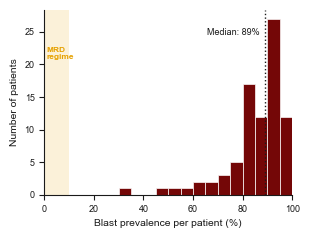

In [3]:
# Per-patient blast prevalence — the structural mismatch that motivates the MRD reframe
pct, median = eda.blast_prevalence_per_patient(y, groups)
fig = figures.plot_blast_prevalence(pct, median)
save_fig(fig, "02a_blast_prevalence")
plt.show()

### Figure X | Class imbalance between the natural token distribution and the rare-class stress-test regime.
1. **Per-patient positive-rate distribution across the cohort ($n = 84$).** The natural corpus is
dominated by a high-positive-rate regime (median ≈ 89 %), whereas the **rare-class stress test**
targets the ultra-rare fraction (0–10 % positive rate) — the regime where inductive biases actually
separate.

2. This **distribution gap creates an evaluation gap**: aggregate metrics like AUROC are inflated
by the high-prevalence majority and mask failures in the rare-token regime. This is why the study
reports the rare-class stress test (AUPRC / sensitivity@FPR / calibration) alongside AUROC — the NLP
analogue of evaluating a rare-intent / rare-entity detector, not just overall accuracy.

## 2. Distribution shift across patients

The headline EDA figure. Embed cells (PCA → UMAP) and colour by (a) patient and (b) blast/normal. If
patients occupy different regions, that *is* the group-level **distribution shift** the evaluation is
stressed under (the analogue of train/test drift in text). Subsample (~20–30k cells) for speed.

/Users/anthonyengelmann/.pyenv/versions/3.12.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


patient-prediction balanced accuracy = 0.73  (chance 0.012, 61x)


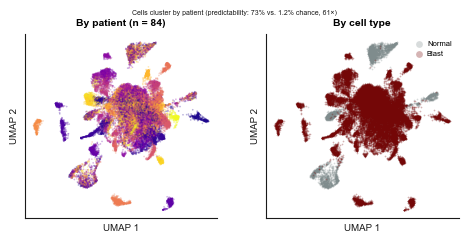

In [4]:
# Distribution shift across patients: UMAP + a "which patient?" probe
shift = eda.patient_shift_embedding(X, y, groups)
print(f"patient-prediction balanced accuracy = {shift['bal_acc']:.2f}  "
      f"(chance {shift['chance']:.3f}, {shift['bal_acc']/shift['chance']:.0f}x)")
fig = figures.plot_patient_shift(**shift)
save_fig(fig, "02b_patient_shift")
plt.show()

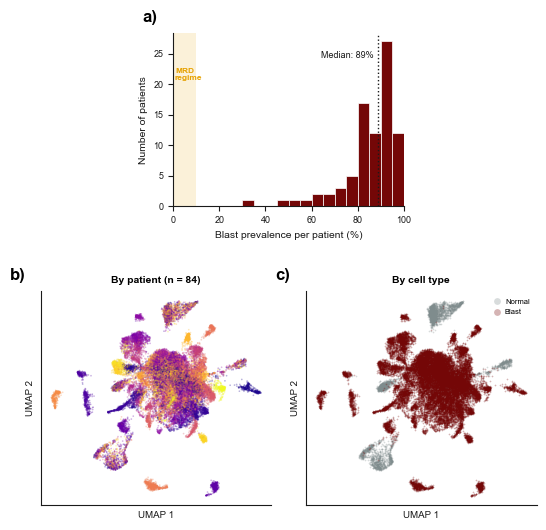

In [6]:
# ── Combined EDA figure: (a) blast prevalence centered on top, (b,c) patient-shift UMAPs below ──
from matplotlib.gridspec import GridSpec
# Reuses pct, median, shift from the 2a/2b cells. To run standalone, uncomment:
# pct, median = eda.blast_prevalence_per_patient(y, groups)
# shift = eda.patient_shift_embedding(X, y, groups)

fig = plt.figure(figsize=(6.4, 6.4))                       # square
gs  = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.35)
axA = fig.add_subplot(gs[0, 1:3])                          # a) centered on top (half width)
axB = fig.add_subplot(gs[1, 0:2])                          # b) bottom-left
axC = fig.add_subplot(gs[1, 2:4])                          # c) bottom-right
axA.set_box_aspect(2.4/3.2)                                # keep 2a's original proportions (no stretch)

# (a) per-patient blast prevalence
axA.axvspan(0, 10, color=STYLE_COLORS["ACCENT"], alpha=0.15, lw=0)
axA.hist(pct, bins=np.arange(0, 101, 5), color=STYLE_COLORS["PRIMARY"], edgecolor="white", lw=0.5)
axA.axvline(median, color=STYLE_COLORS["TEXT"], lw=1, ls=":")
ymax = axA.get_ylim()[1]
axA.text(0.75, ymax*0.80, "MRD\nregime", ha="left", va="top", color=STYLE_COLORS["ACCENT"], size=6, fontweight="bold")
axA.text(median-2, ymax*0.90, f"Median: {median:.0f}%", ha="right", va="top", color=STYLE_COLORS["TEXT"], size=6.5)
axA.set_xlabel("Blast prevalence per patient (%)"); axA.set_ylabel("Number of patients"); axA.set_xlim(0, 100)

# (b) UMAP by patient, (c) UMAP by cell type
pcodes = pd.factorize(shift["gs"])[0]
axB.scatter(shift["emb"][:,0], shift["emb"][:,1], c=pcodes, cmap="plasma", s=1.5, alpha=0.3, lw=0, rasterized=True)
axB.set_title(f"By patient (n = {len(np.unique(shift['gs']))})", fontsize=7.5, fontweight="bold")
for lab, col, name in [(0, STYLE_COLORS["CONTROL"], "Normal"), (1, STYLE_COLORS["PRIMARY"], "Blast")]:
    m = shift["ys"] == lab
    axC.scatter(shift["emb"][m,0], shift["emb"][m,1], c=col, s=1.5, alpha=0.3, lw=0, rasterized=True, label=name)
axC.legend(frameon=False, loc="upper right", markerscale=4, handletextpad=0.1, fontsize=5.5)
axC.set_title("By cell type", fontsize=7.5, fontweight="bold")
for ax in (axB, axC):
    ax.set_xlabel("UMAP 1", fontsize=7); ax.set_ylabel("UMAP 2", fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

# panel labels a) b) c)
for ax, lab in [(axA, "a)"), (axB, "b)"), (axC, "c)")]:
    ax.annotate(lab, xy=(0,1), xycoords="axes fraction", xytext=(-22, 6),
                textcoords="offset points", fontsize=12, fontweight="bold", va="bottom")

save_fig(fig, "02_eda_composite")
plt.show()

## 3. Figure X: Cellular Sparsity and Feature Truncation Analysis

**Context:** To justify the choice of sequence length ($k=256$) and evaluate the information retention of the rank-based tokenization, we analyze the distribution of non-zero highly variable genes (HVGs) per cell and their cumulative expression fraction. This quantitative baseline directly informs the model architecture regarding sequence padding, masking, and input dimensions.

genes/cell: median 133 | 90.3% of cells detect < top_k
top 256 genes capture on average 99.4% of a cell's expression


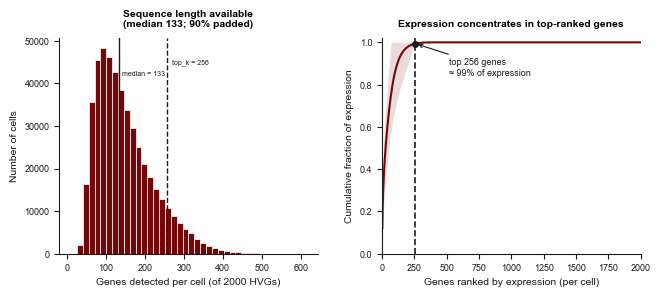

In [10]:
# Cellular sparsity + how much expression the top_k genes capture
stats = eda.sparsity_stats(X, top_k=256)
print(f"genes/cell: median {stats['median_gpc']} | {stats['pad_frac']:.1%} of cells detect < top_k")
print(f"top {stats['top_k']} genes capture on average {stats['cap_at_k']:.1%} of a cell's expression")
fig = figures.plot_token_statistics(stats)
save_fig(fig, "02c_token_statistics")
plt.show()

**Key Findings & Architectural Consequences:**
* **Sparsity-Driven Scale:** The cohort exhibits pronounced sparsity with a median of only **122 detected genes** per cell out of 2,000 HVGs. Consequently, over 90% of cells contain fewer non-zero features than the cap of $k=256$.
* **Sparsity-Inflated Capture:** The average cumulative expression capture of **99.4%** at $k=256$ is largely driven by this sparsity, as most cells are fully described before reaching the threshold and are padded thereafter.
* **Design Decisions:** 
  1. *Attention Masking:* Instead of feeding zero-expression genes as noisy tokens, cells are represented by non-zero genes only and padded using a reserved `PAD_ID`. An internal attention mask (`tokens != PAD_ID`) is required to ignore padded positions during mean-pooling and transformer self-attention.
  2. *Rank+Value Encoding:* This sparsity strongly favors a joint *Rank+Value* representation, ensuring that any residual zero-value tokens remain biologically inert.
  3. *Sequence Length Cap:* A choice of $k=256$ is generous and fully preserves the information in the rich tail of highly expressive cells. However, dropping $k$ toward $128$ remains a viable, compute-efficient alternative ($O(k^2)$ scaling) with negligible signal loss.

## 4. Marker-gene sanity check

Confirm the HVG panel contains known B-ALL / blast markers (e.g. CD19, CD34, MS4A1, CD79A/B) and that they separate blast vs normal — a quick biological sanity check on labels + representation.

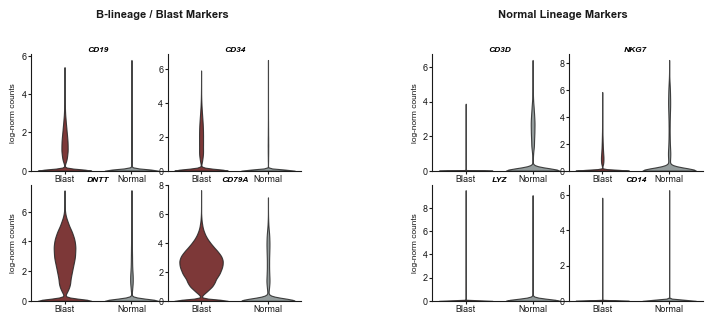

In [11]:
# Marker-gene sanity check (canonical markers, computed on the FULL gene set)
Xm, y_markers, marker_names = eda.load_marker_matrix()
fig = figures.plot_marker_violins(Xm, marker_names, y_markers)
save_fig(fig, "02d_marker_violins")
plt.show()

## 4. Normal-cell availability (bounds the rare-class stress test)

Per-patient normal-cell counts. This is the effective-N ceiling for the rare-class stress-test
negatives (why the shared-negative background matters and how low the positive rate π can honestly
go).

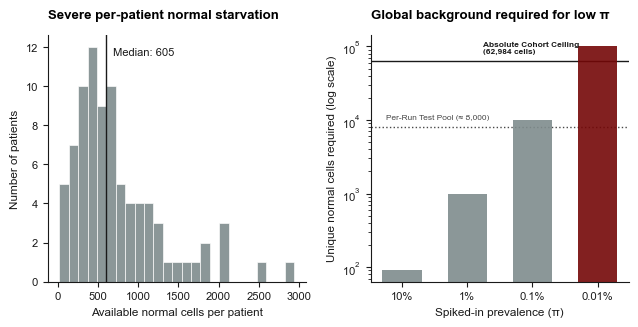

In [12]:
# Normal-cell availability bounds the MRD spike-in (unique normals cap low-pi resolution)
avail = eda.normal_availability(y, groups)
fig = figures.plot_normal_availability(avail)
save_fig(fig, "02e_normal_availability")
plt.show()

**Outputs:** Fig. 1 (`02_umap_patient_shift.pdf`) -> Data section; supporting panels -> appendix.